In [1]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/home/yuanshanwu/Documents/GitHub/QuantUS/engines/ceus/CLI-Demos
/home/yuanshanwu/Documents/GitHub/QuantUS/engines/ceus


## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [2]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['mp4', 'nifti', 'avi']


In [3]:
scan_type = 'nifti'

# Takes the DICOM file as input for contrast enhanced ultrasound (CEUS) scans
CEUS_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_CEUS.nii'
bmode_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_BMODE.nii'
scan_loader_kwargs = {
}

In [4]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, CEUS_scan_path, **scan_loader_kwargs)
bmode_image_data = scan_loading_step(scan_type, bmode_scan_path, **scan_loader_kwargs)

## Load Segmentation

Assumes same segmentation for each frame

In [5]:
from src.seg_loading.options import get_seg_loaders

print("Available segmentation loaders:", list(get_seg_loaders().keys()))

Available segmentation loaders: ['load_bolus_mask', 'nifti']


In [6]:
seg_type = 'nifti'

seg_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/motion_VOI.nii.gz'
seg_loader_kwargs = {}

In [7]:
from src.entrypoints import seg_loading_step

# Testing the motion compensation, right now is hard coded
seg_data = seg_loading_step(seg_type, image_data, seg_path, CEUS_scan_path, **seg_loader_kwargs)

# Implement MEDSAM 2 model

In [8]:
# Use inline backend - MORE RELIABLE for Jupyter
%matplotlib inline

import cv2
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_erosion
import imageio
from PIL import Image
import matplotlib.patches as patches
from tqdm import tqdm

def enhance_bmode_noise(image_slice, p_low_percentile=2.0, p_high_percentile=98.0):
    non_zero = image_slice[image_slice != 0]
    # Compute 10th and 90th percentile on non-zero values
    p_low = np.percentile(non_zero, 2)
    p_high = np.percentile(non_zero, 98)

    # Clip and normalize to 0-255
    clipped_slice = np.clip(image_slice, p_low, p_high)
    normalized_slice = ((clipped_slice - p_low) / (p_high - p_low) * 255).astype(np.uint8)
    
    return normalized_slice


def get_mask_boundary(mask_slice):
    """Extract boundary of a binary mask using erosion."""
    if mask_slice.max() == 0:
        return np.zeros_like(mask_slice, dtype=bool)
    eroded = binary_erosion(mask_slice)
    boundary = mask_slice.astype(bool) & ~eroded
    return boundary

def get_voi_center(mask_3d):
    """Calculate the center of a 3D VOI mask."""
    coords = np.where(mask_3d > 0)
    if len(coords[0]) == 0:
        return None, None, None
    lateral_center = int(np.mean(coords[0]))
    depth_center = int(np.mean(coords[1]))
    elevation_center = int(np.mean(coords[2]))
    return lateral_center, depth_center, elevation_center

In [9]:
import sys
# Add MedSAM2 root to Python path
# From CLI-Demos/, go up 4 levels to QUANTUS/, then into MedSAM2/
medsam2_path = os.path.abspath(os.path.join(os.getcwd(), '..','..','MedSAM2'))
print(f"MedSAM2 path: {medsam2_path}")  # verify it looks right
sys.path.insert(0, medsam2_path)

# load libraries and define necessary functions
from glob import glob
from tqdm import tqdm
import os
from os.path import join, basename
import re
import matplotlib.pyplot as plt
from collections import OrderedDict
import pandas as pd
import numpy as np
import argparse

from PIL import Image
import SimpleITK as sitk
import torch
import torch.multiprocessing as mp
import SimpleITK as sitk
from skimage import measure, morphology

MedSAM2 path: /home/yuanshanwu/Documents/GitHub/QuantUS/MedSAM2


## 3D segmentation using sagittal and coronal as the input for the bounding box
There are two way to approach this issue
1) We could segment out the axial,sagitall and coronal plane and then do an interpolation to 3d which is similar to what quantus have done.
2) we could use the x-plane information to generate an adaptive bounding box on the z plane where sagittal and coronal can provide x min to x max, y min to y max on each individual slice z. This way we are basically giving new bounding box information

In [13]:
import torch
import numpy as np
import os
os.environ["QT_API"] = "pyqt6"
import napari
import time
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# ── Load model ────────────────────────────────────────────────────────────────
checkpoint = '/home/yuanshanwu/Documents/GitHub/QuantUS/MedSAM2/checkpoints/MedSAM2_MRI_LiverLesion.pt'
model_cfg  = "configs/sam2.1_hiera_t512.yaml"
sam2_model = build_sam2(model_cfg, checkpoint, device="cuda")
image_predictor = SAM2ImagePredictor(sam2_model)

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────
def slice_to_rgb(slice_2d):
    """Normalize a 2D slice to uint8 RGB."""
    s_min, s_max = slice_2d.min(), slice_2d.max()
    uint8 = ((slice_2d - s_min) / (s_max - s_min + 1e-8) * 255).astype(np.uint8)
    return np.stack([uint8] * 3, axis=-1)


def run_medsam2_2d(image_predictor, slice_2d, bbox_2d, device="cuda"):
    """
    Run SAM2ImagePredictor on one 2D slice.
    slice_2d : (H, W) float   — already in display orientation
    bbox_2d  : [x_min, y_min, x_max, y_max]
    Returns  : (H, W) bool mask, or None if bbox is degenerate
    """
    # Skip degenerate bboxes (zero width or height)
    x_min, y_min, x_max, y_max = bbox_2d
    if (x_max - x_min) < 2 or (y_max - y_min) < 2:
        return None

    rgb = slice_to_rgb(slice_2d)
    with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
        image_predictor.set_image(rgb)
        masks, _, _ = image_predictor.predict(
            point_coords=None,
            point_labels=None,
            box=np.array(bbox_2d, dtype=np.float32)[None, :],
            multimask_output=False,
        )
    return masks[0].astype(bool)                               # (H, W)


def get_adaptive_bbox_at_z(coronal_mask, sagittal_mask, z_abs, bbox, padding=4):
    """
    Derive a tight 2D bbox for axial slice at z_abs using coronal + sagittal masks.

    coronal_mask  : (X, Z) — from SAM2 on volume[:, y_mid, :]
    sagittal_mask : (Y, Z) — from SAM2 on volume[x_mid, :, :]
    z_abs         : absolute Z index in the full volume
    bbox          : BoundingBox3D — used for z_min offset and fallback bounds
    padding       : extra pixels added around the derived bbox

    Returns: [x_min, y_min, x_max, y_max] or None if no mask at this z
    """
    z_rel = z_abs                    # relative index into coronal/sagittal masks

    # X extent from coronal mask (X, Z) — which X pixels are active at this z?
    coronal_col = coronal_mask[:, int(z_rel)]          # (X,)
    x_active    = np.where(coronal_col)[0]

    # Y extent from sagittal mask (Y, Z) — which Y pixels are active at this z?
    sagittal_col = sagittal_mask[:, int(z_rel)]        # (Y,)
    y_active     = np.where(sagittal_col)[0]

    # If either plane has no active pixels at this Z, skip the slice
    if len(x_active) == 0 or len(y_active) == 0:
        return None

    # Build tight bbox with padding, clamped to volume bounds
    x_min = max(0,               x_active.min() - padding)
    x_max = min(bbox.x_max + padding, x_active.max() + padding)
    y_min = max(0,               y_active.min() - padding)
    y_max = min(bbox.y_max + padding, y_active.max() + padding)

    return [x_min, y_min, x_max, y_max]


# ─────────────────────────────────────────────────────────────────────────────
# Main: single frame 3D segmentation
# ─────────────────────────────────────────────────────────────────────────────
frame_idx = 0                                     # ← change to any frame you want

bbox    = seg_data.motion_compensation.tracked_bboxes[frame_idx]
volume  = bmode_image_data.pixel_data[:, :, :, frame_idx]      # (X, Y, Z)
mc_mask = seg_data.motion_compensation.apply_to_mask(
              seg_data.seg_mask, frame_idx, 0)                  # (X, Y, Z)

# Derive best slice centres from MC mask
z_mid = int(np.argmax(mc_mask.sum(axis=(0, 1))))
y_mid = int(np.argmax(mc_mask.sum(axis=(0, 2))))
x_mid = int(np.argmax(mc_mask.sum(axis=(1, 2))))

print(f"Frame {frame_idx} | z_mid={z_mid}  y_mid={y_mid}  x_mid={x_mid}")
print(f"BBox: X=[{bbox.x_min},{bbox.x_max}]  "
      f"Y=[{bbox.y_min},{bbox.y_max}]  "
      f"Z=[{bbox.z_min},{bbox.z_max}]")

start_time = time.time()
# ── Step 1: Segment coronal at y_mid → (X, Z) ────────────────────────────────
print("\nStep 1: Segmenting coronal plane...")
coronal_slice = volume[:, y_mid, :]                            # (X, Z)
coronal_bbox  = np.array([bbox.z_min, bbox.x_min,
                           bbox.z_max, bbox.x_max], dtype=np.float32)
coronal_mask  = run_medsam2_2d(image_predictor, coronal_slice, coronal_bbox)
# coronal_mask shape: (X, Z) — H=X rows, W=Z cols in display, so transpose back
# run_medsam2_2d returns (H, W) = (X, Z) since we did NOT transpose coronal_slice
# coronal_mask is already (X, Z) ✓
print(f"  Coronal mask: {coronal_mask.sum()} active pixels")

# ── Step 2: Segment sagittal at x_mid → (Y, Z) ───────────────────────────────
print("\nStep 2: Segmenting sagittal plane...")
sagittal_slice = volume[x_mid, :, :]                           # (Y, Z)
sagittal_bbox  = np.array([bbox.z_min, bbox.y_min,
                            bbox.z_max, bbox.y_max], dtype=np.float32)
sagittal_mask  = run_medsam2_2d(image_predictor, sagittal_slice, sagittal_bbox)
# sagittal_mask is (Y, Z) ✓
print(f"  Sagittal mask: {sagittal_mask.sum()} active pixels")

# ── Step 3: Per-axial-slice segmentation with adaptive bbox ───────────────────
print(f"\nStep 3: Segmenting axial slices z={bbox.z_min} → z={bbox.z_max}...")
mask_3d = np.zeros(volume.shape, dtype=np.uint8)               # (X, Y, Z)

n_segmented = 0
n_skipped   = 0
save_adaptive_bbox = np.zeros((4, int(bbox.z_max - bbox.z_min)))

for abs_z in range(int(bbox.z_min), int(bbox.z_max)):

    # Derive slice-specific bbox from coronal + sagittal guidance
    adaptive_bbox = get_adaptive_bbox_at_z(
        coronal_mask, sagittal_mask, abs_z, bbox, padding=0
    )

    if adaptive_bbox is None:
        n_skipped += 1
        continue                                               # leave as zeros

    # Axial slice — transpose to (Y, X) to match visualization convention
    axial_slice = volume[:, :, abs_z].T                        # (Y, X)

    # Run SAM2 — bbox is [x_min, y_min, x_max, y_max] in (Y, X) image space
    # x→col=X(lateral), y→row=Y(depth) after transpose ✓
    pred_yx = run_medsam2_2d(image_predictor, axial_slice, adaptive_bbox)

    save_adaptive_bbox[:,abs_z-int(bbox.z_min)] = adaptive_bbox
    
    if pred_yx is not None:
        mask_3d[:, :, abs_z] = pred_yx.T                      # (Y,X)→(X,Y)
        n_segmented += 1
    else:
        n_skipped += 1

elapsed = time.time() - start_time
print(f"\nInference completed in {elapsed:.1f} seconds")
print(f"  Segmented: {n_segmented} slices  |  Skipped: {n_skipped} slices")
print(f"  3D mask active voxels: {mask_3d.sum()}")

Frame 0 | z_mid=94  y_mid=121  x_mid=211
BBox: X=[183.0,246.0]  Y=[95.0,151.0]  Z=[61.0,135.0]

Step 1: Segmenting coronal plane...
  Coronal mask: 3312 active pixels

Step 2: Segmenting sagittal plane...
  Sagittal mask: 2494 active pixels

Step 3: Segmenting axial slices z=61.0 → z=135.0...

Inference completed in 2.5 seconds
  Segmented: 67 slices  |  Skipped: 7 slices
  3D mask active voxels: 88173


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Napari visualization
# ─────────────────────────────────────────────────────────────────────────────
print("\nLaunching napari...")

# Napari expects (Z, Y, X) for standard volume display
# Our volume is (X, Y, Z) → transpose to (Z, Y, X)
volume_zyx  = volume.T                                         # (Z, Y, X)
sam2_zyx    = mask_3d.T.astype(np.uint8)                       # (Z, Y, X)
mc_zyx      = mc_mask.T.astype(np.uint8)                       # (Z, Y, X)

viewer = napari.Viewer(title=f"MedSAM2 3D vs MC mask — Frame {frame_idx}")

# B-mode volume
viewer.add_image(
    volume_zyx,  # focus on the region around the lesion for better visibility
    name="B-mode volume",
    colormap="gray",
    blending="additive",
)

# MC mask — red, semi-transparent
viewer.add_labels(
    mc_zyx,
    name="MC mask (reference)",
    colormap={1: "red", None: "transparent"},
    opacity=0.4,
)

# MedSAM2 3D mask — green, semi-transparent
viewer.add_labels(
    sam2_zyx,
    name="MedSAM2 3D mask",
    opacity=0.4,
)

# Show the guidance planes as image layers for reference
viewer.add_image(
    coronal_slice.T,                                           # napari wants (Z, X) for a ZX plane
    name=f"Coronal slice (Y={y_mid})",
    colormap="gray",
    visible=False,                                             # hidden by default, toggle in GUI
)

napari.run()


Launching napari...


## Adding in the 4D movement of the tumor

In [37]:
import os
os.environ["QT_API"] = "pyqt6"

import napari
import numpy as np
import torch
from functools import lru_cache

# ── Cache to avoid recomputing visited frames ─────────────────────────────────
frame_cache = {}

def compute_frame(frame_idx):
    """Compute SAM2 3D mask for a single frame. Uses cache if available."""
    if frame_idx in frame_cache:
        return frame_cache[frame_idx]

    bbox    = seg_data.motion_compensation.tracked_bboxes[frame_idx]
    volume  = bmode_image_data.pixel_data[:, :, :, frame_idx]  # (X, Y, Z)
    mc_mask = seg_data.motion_compensation.apply_to_mask(
                  seg_data.seg_mask, frame_idx, 0)              # (X, Y, Z)
    
    # Original 3D bbox — yellow
    # Construct the 6 faces of the bounding box
    # Z_START = 89  # your crop start

    # # Clamp and offset bbox z coordinates to cropped volume space
    # z_min_cropped = bbox.z_min - Z_START
    # z_max_cropped = bbox.z_max - Z_START

    # bbox_faces = [
    #     # Bottom face (z_min)
    #     np.array([
    #         [z_min_cropped, bbox.y_min, bbox.x_min],
    #         [z_min_cropped, bbox.y_min, bbox.x_max],
    #         [z_min_cropped, bbox.y_max, bbox.x_max],
    #         [z_min_cropped, bbox.y_max, bbox.x_min],
    #     ]),
    #     # Top face (z_max)
    #     np.array([
    #         [z_max_cropped, bbox.y_min, bbox.x_min],
    #         [z_max_cropped, bbox.y_min, bbox.x_max],
    #         [z_max_cropped, bbox.y_max, bbox.x_max],
    #         [z_max_cropped, bbox.y_max, bbox.x_min],
    #     ]),
    #     # Front face (y_min)
    #     np.array([
    #         [z_min_cropped, bbox.y_min, bbox.x_min],
    #         [z_min_cropped, bbox.y_min, bbox.x_max],
    #         [z_max_cropped, bbox.y_min, bbox.x_max],
    #         [z_max_cropped, bbox.y_min, bbox.x_min],
    #     ]),
    #     # Back face (y_max)
    #     np.array([
    #         [z_min_cropped, bbox.y_max, bbox.x_min],
    #         [z_min_cropped, bbox.y_max, bbox.x_max],
    #         [z_max_cropped, bbox.y_max, bbox.x_max],
    #         [z_max_cropped, bbox.y_max, bbox.x_min],
    #     ]),
    #     # Left face (x_min)
    #     np.array([
    #         [z_min_cropped, bbox.y_min, bbox.x_min],
    #         [z_min_cropped, bbox.y_max, bbox.x_min],
    #         [z_max_cropped, bbox.y_max, bbox.x_min],
    #         [z_max_cropped, bbox.y_min, bbox.x_min],
    #     ]),
    #     # Right face (x_max)
    #     np.array([
    #         [z_min_cropped, bbox.y_min, bbox.x_max],
    #         [z_min_cropped, bbox.y_max, bbox.x_max],
    #         [z_max_cropped, bbox.y_max, bbox.x_max],
    #         [z_max_cropped, bbox.y_min, bbox.x_max],
    #     ]),
    # ]

    # Best slice centres from MC mask
    z_mid = int(np.argmax(mc_mask.sum(axis=(0, 1))))
    y_mid = int(np.argmax(mc_mask.sum(axis=(0, 2))))
    x_mid = int(np.argmax(mc_mask.sum(axis=(1, 2))))

    # Step 1: coronal guidance
    coronal_slice = volume[:, y_mid, :]
    coronal_bbox  = np.array([bbox.z_min, bbox.x_min,
                               bbox.z_max, bbox.x_max], dtype=np.float32)
    coronal_mask  = run_medsam2_2d(image_predictor, coronal_slice, coronal_bbox)

    # Step 2: sagittal guidance
    sagittal_slice = volume[x_mid, :, :]
    sagittal_bbox  = np.array([bbox.z_min, bbox.y_min,
                                bbox.z_max, bbox.y_max], dtype=np.float32)
    sagittal_mask  = run_medsam2_2d(image_predictor, sagittal_slice, sagittal_bbox)

    # Step 3: per-axial-slice segmentation with adaptive bbox
    mask_3d = np.zeros(volume.shape, dtype=np.uint8)  # (X, Y, Z)

    for abs_z in range(int(bbox.z_min), int(bbox.z_max)):
        adaptive_bbox = get_adaptive_bbox_at_z(
            coronal_mask, sagittal_mask, abs_z, bbox, padding=4
        )
        if adaptive_bbox is None:
            continue

        axial_slice = volume[:, :, abs_z].T            # (Y, X)
        pred_yx     = run_medsam2_2d(image_predictor, axial_slice, adaptive_bbox)

        if pred_yx is not None:
            mask_3d[:, :, abs_z] = pred_yx.T          # (Y, X) → (X, Y)

    volume_ceus = image_data.pixel_data[:, :, :, frame_idx]  # (X, Y, Z)
    # Cache result
    frame_cache[frame_idx] = {
        "volume":   volume_ceus,
        "mc_mask":  mc_mask,
        "sam2_mask": mask_3d,
        # "bbox_faces": bbox_faces,
    }

    return frame_cache[frame_idx]

# ── Precompute frame 0 to initialise the viewer ───────────────────────────────
print("Computing frame 0...")
result      = compute_frame(0)
volume_zyx  = result["volume"].T.astype(np.float32)    # (Z, Y, X)
mc_zyx      = result["mc_mask"].T.astype(np.uint8)     # (Z, Y, X)
sam2_zyx    = result["sam2_mask"].T.astype(np.uint8)   # (Z, Y, X)
# bbox_zyx    = result["bbox_faces"]   # (Z, Y, X)
print("Done. Launching napari...")

# ── Launch napari ──────────────────────────────────────────────────────────────
viewer = napari.Viewer(title="MedSAM2 3D — on-demand segmentation")

bmode_layer = viewer.add_image(
    volume_zyx,
    name="B-mode volume",
    colormap="gray",
    blending="additive",
)

mc_layer = viewer.add_labels(
    mc_zyx,
    name="MC mask (reference)",
    opacity=0.5,
)

sam2_layer = viewer.add_labels(
    sam2_zyx,
    name="MedSAM2 3D mask",
    colormap={1: "red", None: "transparent"},
    opacity=0.5,
)

# bbox_layer = viewer.add_shapes(
#     bbox_zyx,
#     shape_type='polygon',
#     edge_color='yellow',
#     face_color='transparent',
#     edge_width=2,
#     name='Bounding box',
# )

# Status label in napari
status_label = viewer.text_overlay
status_label.visible = True
status_label.text    = "Frame 0 — ready"

# ── Callback: fires when the T slider changes ──────────────────────────────────
# We add a dummy T dimension so napari gives us a frame slider
# Wrap each layer as (T=1, Z, Y, X) — napari will show a T slider
# once we update dynamically

current_frame = {"idx": 0}   # mutable container to track state

def on_frame_change(event):
    """Called when user drags the frame slider."""
    # napari dims order for a 3D volume is (Z, Y, X)
    # We use a separate IntSlider widget for frame control
    pass  # replaced by the slider below

# ── Add a frame slider as a napari dock widget ────────────────────────────────
from qtpy.QtWidgets import QSlider, QLabel, QVBoxLayout, QWidget
from qtpy.QtCore    import Qt

n_frames = image_data.pixel_data.shape[-1]

class FrameControlWidget(QWidget):
    def __init__(self):
        super().__init__()
        layout = QVBoxLayout()

        self.label = QLabel("Frame: 0")
        self.label.setAlignment(Qt.AlignmentFlag.AlignCenter)

        self.slider = QSlider(Qt.Orientation.Horizontal)
        self.slider.setMinimum(0)
        self.slider.setMaximum(n_frames - 1)
        self.slider.setValue(0)
        self.slider.setTickInterval(10)
        self.slider.setTickPosition(QSlider.TickPosition.TicksBelow)

        self.slider.valueChanged.connect(self.on_slider_changed)

        layout.addWidget(self.label)
        layout.addWidget(self.slider)
        self.setLayout(layout)

    def on_slider_changed(self, frame_idx):
        self.label.setText(f"Frame: {frame_idx}  (computing...)")

        # Compute or retrieve from cache
        result = compute_frame(frame_idx)

        # Update layers in place — no viewer restart needed
        bmode_layer.data = result["volume"].T.astype(np.float32)
        mc_layer.data    = result["mc_mask"].T.astype(np.uint8)
        sam2_layer.data  = result["sam2_mask"].T.astype(np.uint8)
        # bbox_layer.data    = result["bbox_faces"]   # (Z, Y, X)

        self.label.setText(
            f"Frame: {frame_idx}  |  "
            f"SAM2 voxels: {result['sam2_mask'].sum()}  |  "
            f"MC voxels: {result['mc_mask'].sum()}"
        )

frame_widget = FrameControlWidget()
viewer.window.add_dock_widget(
    frame_widget,
    name="Frame Control",
    area="bottom",
)

print(f"Napari ready — {n_frames} frames available")
print("Use the bottom slider to scrub through frames")

Computing frame 0...
Done. Launching napari...
Napari ready — 530 frames available
Use the bottom slider to scrub through frames


### Drawing TIC curves for both

In [11]:
frame_cache = {}

def compute_frame(frame_idx):
    """Compute SAM2 3D mask for a single frame. Uses cache if available."""
    if frame_idx in frame_cache:
        return frame_cache[frame_idx]

    bbox    = seg_data.motion_compensation.tracked_bboxes[frame_idx]
    volume  = bmode_image_data.pixel_data[:, :, :, frame_idx]  # (X, Y, Z)
    mc_mask = seg_data.motion_compensation.apply_to_mask(
                  seg_data.seg_mask, frame_idx, 0)              # (X, Y, Z)
    
    # Best slice centres from MC mask
    z_mid = int(np.argmax(mc_mask.sum(axis=(0, 1))))
    y_mid = int(np.argmax(mc_mask.sum(axis=(0, 2))))
    x_mid = int(np.argmax(mc_mask.sum(axis=(1, 2))))

    # Step 1: coronal guidance
    coronal_slice = volume[:, y_mid, :]
    coronal_bbox  = np.array([bbox.z_min, bbox.x_min,
                               bbox.z_max, bbox.x_max], dtype=np.float32)
    coronal_mask  = run_medsam2_2d(image_predictor, coronal_slice, coronal_bbox)

    # Step 2: sagittal guidance
    sagittal_slice = volume[x_mid, :, :]
    sagittal_bbox  = np.array([bbox.z_min, bbox.y_min,
                                bbox.z_max, bbox.y_max], dtype=np.float32)
    sagittal_mask  = run_medsam2_2d(image_predictor, sagittal_slice, sagittal_bbox)

    # Step 3: per-axial-slice segmentation with adaptive bbox
    mask_3d = np.zeros(volume.shape, dtype=np.uint8)  # (X, Y, Z)

    for abs_z in range(int(bbox.z_min), int(bbox.z_max)):
        adaptive_bbox = get_adaptive_bbox_at_z(
            coronal_mask, sagittal_mask, abs_z, bbox, padding=4
        )
        if adaptive_bbox is None:
            continue

        axial_slice = volume[:, :, abs_z].T            # (Y, X)
        pred_yx     = run_medsam2_2d(image_predictor, axial_slice, adaptive_bbox)

        if pred_yx is not None:
            mask_3d[:, :, abs_z] = pred_yx.T          # (Y, X) → (X, Y)

    volume_ceus = image_data.pixel_data[:, :, :, frame_idx]  # (X, Y, Z)
    # Cache result
    frame_cache[frame_idx] = {
        "volume":   volume_ceus,
        "mc_mask":  mc_mask,
        "sam2_mask": mask_3d,
        # "bbox_faces": bbox_faces,
    }

    return frame_cache[frame_idx]

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# TIC Computation — MedSAM2 vs Motion Compensated Mask
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Config ────────────────────────────────────────────────────────────────────
START_FRAME = 0
END_FRAME   = bmode_image_data.pixel_data.shape[-1]  # all frames, or set manually

# ── TIC computation ───────────────────────────────────────────────────────────
def compute_tic_from_mask(mask_xyz, volume_xyz):
    """
    Compute mean intensity inside mask for a single frame.
    
    Args:
        mask_xyz:   binary mask  (X, Y, Z)
        volume_xyz: CEUS frame   (X, Y, Z)
    Returns:
        float: mean intensity, or NaN if mask is empty
    """
    voxels = volume_xyz[mask_xyz > 0]
    if len(voxels) == 0:
        return np.nan
    return float(np.mean(voxels))


def compute_volume_from_mask(mask_xyz, voxel_volume_mm3):
    """
    Compute volume in mm^3 from binary mask.
    
    Args:
        mask_xyz: binary mask (X, Y, Z)
        voxel_volume_mm3: volume of one voxel in mm^3

    Returns:
        float: volume in mm^3, or 0 if mask is empty
    """
    if np.sum(mask_xyz) == 0:
        return 0
    return float(np.sum(mask_xyz) * voxel_volume_mm3)


# ── Loop over frames ──────────────────────────────────────────────────────────
tic_sam2 = []   # TIC from MedSAM2 mask
tic_mc   = []   # TIC from motion compensated mask
vol_sam2 = []   # Volume from MedSAM2 mask
vol_mc   = []   # Volume from motion compensated mask
frames_computed = []

for frame_idx in tqdm(range(START_FRAME, END_FRAME), desc="Computing TICs"):

    # ── Get CEUS intensity volume for this frame ──────────────────────────────
    # Use linearized intensities if available, otherwise pixel data
    if hasattr(image_data, 'intensities_for_analysis'):
        ceus_volume = image_data.intensities_for_analysis[:, :, :, frame_idx]  # (X, Y, Z)
    else:
        ceus_volume = image_data.pixel_data[:, :, :, frame_idx]                # (X, Y, Z)

    # ── Get masks ─────────────────────────────────────────────────────────────
    # MedSAM2 mask — compute on demand (uses cache if already visited)
    result       = compute_frame(frame_idx)
    sam2_mask    = result["sam2_mask"]   # (X, Y, Z)
    # sam2_mask =  seg_data.motion_compensation.apply_to_mask(
    #                    seg_data.seg_mask, frame_idx, 0)  # (X, Y, Z)

    # MC mask — apply motion compensation to reference segmentation
    mc_mask      = seg_data.seg_mask
    
    # ── Compute mean intensity inside each mask ───────────────────────────────
    tic_sam2.append(compute_tic_from_mask(sam2_mask, ceus_volume))
    tic_mc.append(compute_tic_from_mask(mc_mask,   ceus_volume))
    frames_computed.append(frame_idx)
    
    voxel_vol = float(np.prod(image_data.pixdim))  # mm^3
    vol_sam2.append(compute_volume_from_mask(sam2_mask, voxel_vol))
    vol_mc.append(compute_volume_from_mask(mc_mask, voxel_vol))

tic_sam2 = np.array(tic_sam2)
tic_mc   = np.array(tic_mc)
frames   = np.array(frames_computed)

# ── Convert frame index to time axis if frame rate is available ───────────────
if hasattr(image_data, 'frame_rate') and image_data.frame_rate > 0:
    time_axis  = frames * image_data.frame_rate   # seconds
    x_label    = "Time (s)"
else:
    time_axis  = frames
    x_label    = "Frame index"

print(f"Computed TICs over {len(frames)} frames")
print(f"  SAM2  — min: {np.nanmin(tic_sam2):.4f}  max: {np.nanmax(tic_sam2):.4f}  NaN frames: {np.isnan(tic_sam2).sum()}")
print(f"  MC    — min: {np.nanmin(tic_mc):.4f}    max: {np.nanmax(tic_mc):.4f}    NaN frames: {np.isnan(tic_mc).sum()}")


Computing TICs: 100%|██████████| 530/530 [07:45<00:00,  1.14it/s]

Computed TICs over 530 frames
  SAM2  — min: 21.4811  max: 83.4237  NaN frames: 0
  MC    — min: 20.5915    max: 74.3831    NaN frames: 0


In [35]:
import numpy as np
from scipy.optimize import curve_fit

def bolus_lognormal(x, auc, mu, sigma, t0):
    with np.errstate(divide='ignore', invalid='ignore'):
        shifted = x - t0
        result = (auc / (shifted * sigma * np.sqrt(2 * np.pi))) * np.exp(-((np.log(shifted) - mu) ** 2) / (2 * sigma ** 2))
        result = np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)
    return result

def fit_lognormal_curve(time, curve):
    """
    Fit a log-normal distribution to the given curve.
    
    Args:
        time (np.ndarray): The time array corresponding to the curve.
        curve (np.ndarray): The curve data to fit.
    
    Returns:
        tuple: Fitted parameters (auc, pe, tp, mtt, t0, mu, sigma, pe_loc).
    """
    curve -= np.amin(curve)  # Shift to start at zero
    if np.amax(curve) == 0:
        print("Curve is constant, cannot normalize.")
        return tuple(np.nan for _ in range(8))
    normalizer = np.amax(curve)
    curve = curve / normalizer  # Normalize

    auc_guess = np.sum(curve) * (time[1] - time[0])
    mu_guess = np.log(np.argmax(curve))
    sigma_guess = 0.5
    t0_guess = time[np.argmax(curve)] * 0.15

    # Define physically reasonable bounds to prevent parameter explosion
    mu_max = np.log(time[-1]) if time[-1] > 0 else 10.0
    auc_max = (np.sum(curve) * (time[1] - time[0])) * 10.0  # 10x the initial guess
    
    auc_guess = min(auc_guess, auc_max)
    mu_guess = min(mu_guess, mu_max)

    try:
        params, _ = curve_fit(
            bolus_lognormal,
            time,
            curve,
            p0=(auc_guess, mu_guess, sigma_guess, t0_guess),
            bounds=([0., 0., 0.01, 0.], [auc_max, mu_max, 5.0, time[-1]]),
            method='trf',
            maxfev=10000  # Increase evaluations
        )
    except Exception as e:
        print(f"Error fitting curve: {e}")
        return tuple(np.nan for _ in range(8))

    auc, mu, sigma, t0 = params
    auc = auc * normalizer  # Scale back to original units
    mtt = np.exp(mu + sigma**2 / 2)
    tp = np.exp(mu - sigma**2)

    # Reject unreasonable fits
    # if tp > time[-1] or mtt > time[-1] * 2 or auc > auc_max:
    #     return tuple(np.nan for _ in range(8))

    fitted_curve = bolus_lognormal(time, *params)
    pe = np.max(fitted_curve)
    pe = pe * normalizer  # Scale back to original units
    pe_loc = np.argmax(fitted_curve)

    return auc, pe, tp, mtt, t0, mu, sigma, pe_loc

outcome_SAM2 = fit_lognormal_curve(time_axis, tic_sam2)
outcome_mask = fit_lognormal_curve(time_axis, tic_mc)


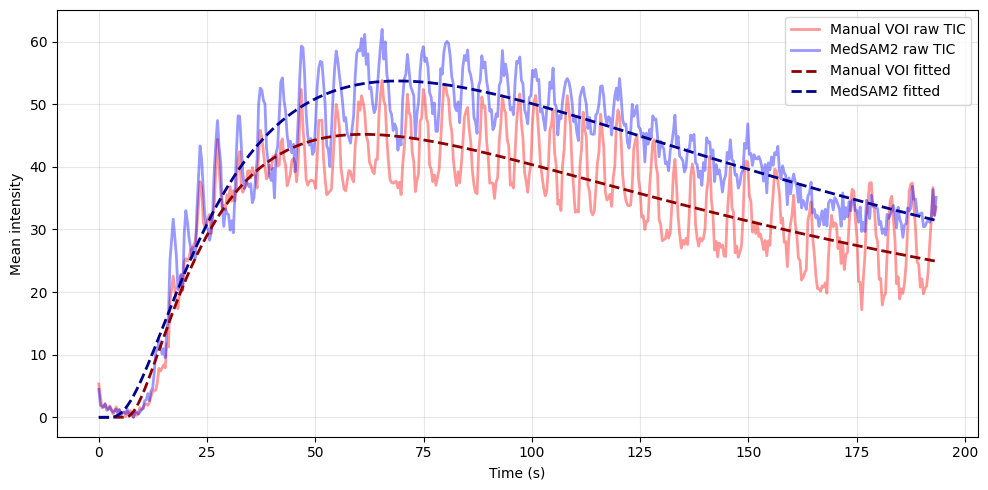


── Lognormal fit parameters ──────────────────────────────────
Parameter         MC mask      MedSAM2
──────────────────────────────────────
AUC            13111.1502   15261.4977
PE                45.1873      53.7070
TP                55.5208      67.4231
MTT              360.9175     311.2385
T0                 5.5636       1.7005
mu                 5.2647       5.2307
sigma              1.1171       1.0098
──────────────────────────────────────

── TIC quality metrics ───────────────────────────────────────
Metric            MC mask      MedSAM2    Δ (SAM2−MC)
────────────────────────────────────────────────────
r2                 0.8213       0.9095        +0.0883
roughness          2.4204       2.1717        -0.2487
snr               31.5162      51.4990       +19.9828
auc            13111.1502   15261.4977     +2150.3475
pe                45.1873      53.7070        +8.5197
tp                55.5208      67.4231       +11.9024
mtt              360.9175     311.2385       -49.67

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# Reconstruct fitted curves from lognormal parameters
# ─────────────────────────────────────────────────────────────────────────────
def reconstruct_fitted_curve(time, outcome):
    """Reconstruct the fitted lognormal curve from fit_lognormal_curve output."""
    auc, pe, tp, mtt, t0, mu, sigma, pe_loc = outcome
    if np.isnan(auc):
        return np.full_like(time, np.nan, dtype=float)
    return bolus_lognormal(time, auc, mu, sigma, t0)


def tic_quality_metrics(time, tic_raw, outcome):
    """Assess lognormal fit quality and curve smoothness."""
    auc, pe, tp, mtt, t0, mu, sigma, pe_loc = outcome

    # Fit quality — R² between raw TIC and fitted curve
    fitted = reconstruct_fitted_curve(time, outcome)
    valid  = ~np.isnan(fitted)
    ss_res = np.sum((tic_raw[valid] - fitted[valid]) ** 2)
    ss_tot = np.sum((tic_raw[valid] - tic_raw[valid].mean()) ** 2)
    r2     = 1 - ss_res / (ss_tot + 1e-8)

    # Curve smoothness — lower = smoother
    roughness = np.mean(np.abs(np.diff(tic_raw)))

    # Signal-to-noise proxy — peak / baseline noise
    baseline_noise = np.std(tic_raw[:5])   # first 5 frames as baseline
    snr = pe / (baseline_noise + 1e-8)

    return {
        'r2':        r2,
        'roughness': roughness,
        'snr':       snr,
        'auc':       auc,
        'pe':        pe,
        'tp':        tp,
        'mtt':       mtt,
        't0':        t0,
    }


fitted_sam2 = reconstruct_fitted_curve(time_axis, outcome_SAM2)
fitted_mc   = reconstruct_fitted_curve(time_axis, outcome_mask)
# ─────────────────────────────────────────────────────────────────────────────
# Reconstruct fitted curves
# ─────────────────────────────────────────────────────────────────────────────
fitted_sam2 = reconstruct_fitted_curve(time_axis, outcome_SAM2)
fitted_mc   = reconstruct_fitted_curve(time_axis, outcome_mask)

# ─────────────────────────────────────────────────────────────────────────────
# Plot both TICs + fits on the same axes
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Raw TICs
ax.plot(time_axis, tic_mc,    color='red',      linewidth=2, alpha=0.4, label='Manual VOI raw TIC')
ax.plot(time_axis, tic_sam2,  color='blue',     linewidth=2, alpha=0.4, label='MedSAM2 raw TIC')

# Fitted curves
ax.plot(time_axis, fitted_mc,   color='darkred',  linewidth=2, linestyle='--', label='Manual VOI fitted')
ax.plot(time_axis, fitted_sam2, color='darkblue', linewidth=2, linestyle='--', label='MedSAM2 fitted')


# ax.set_title('TIC + Lognormal Fit — MedSAM2 vs MC mask', fontsize=13)
ax.set_xlabel(x_label)
ax.set_ylabel('Mean intensity')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Parameter comparison table ────────────────────────────────────────────────
print("\n── Lognormal fit parameters ──────────────────────────────────")
print(f"{'Parameter':<12} {'MC mask':>12} {'MedSAM2':>12}")
print("─" * 38)
params_labels = ['AUC', 'PE', 'TP', 'MTT', 'T0', 'mu', 'sigma']
for label, v_mc, v_s2 in zip(params_labels, outcome_mask[:7], outcome_SAM2[:7]):
    print(f"{label:<12} {v_mc:>12.4f} {v_s2:>12.4f}")
print("─" * 38)

metrics_mc   = tic_quality_metrics(time_axis, tic_mc,   outcome_mask)
metrics_sam2 = tic_quality_metrics(time_axis, tic_sam2, outcome_SAM2)

print("\n── TIC quality metrics ───────────────────────────────────────")
print(f"{'Metric':<12} {'MC mask':>12} {'MedSAM2':>12} {'Δ (SAM2−MC)':>14}")
print("─" * 52)
for k in metrics_mc:
    v_mc  = metrics_mc[k]
    v_s2  = metrics_sam2[k]
    delta = v_s2 - v_mc
    print(f"{k:<12} {v_mc:>12.4f} {v_s2:>12.4f} {delta:>+14.4f}")

## Visualizing how the bounding box being predicted

In [ ]:
# ── Fixed get_adaptive_bbox_at_z — use z_abs directly ────────────────────────
def get_adaptive_bbox_at_z(coronal_mask, sagittal_mask, z_abs, bbox, padding=4):
    """
    coronal_mask  : (X, Z_full) — full volume Z space
    sagittal_mask : (Y, Z_full) — full volume Z space
    z_abs         : absolute Z index — used directly, no offset
    """
    # X extent from coronal mask at z_abs directly
    coronal_col  = coronal_mask[:, z_abs]       # (X,)
    x_active     = np.where(coronal_col)[0]

    # Y extent from sagittal mask at z_abs directly
    sagittal_col = sagittal_mask[:, z_abs]      # (Y,)
    y_active     = np.where(sagittal_col)[0]

    if len(x_active) == 0 or len(y_active) == 0:
        return None

    x_min = max(0,                 x_active.min() - padding)
    x_max = min(volume.shape[0],   x_active.max() + padding)
    y_min = max(0,                 y_active.min() - padding)
    y_max = min(volume.shape[1],   y_active.max() + padding)

    return [x_min, y_min, x_max, y_max]


# ── Rebuild mask_3d with fix + save adaptive bboxes ───────────────────────────
mask_3d          = np.zeros(volume.shape, dtype=np.uint8)  # (X, Y, Z)
saved_adaptive_bboxes = {}   # abs_z → [x_min, y_min, x_max, y_max]

n_segmented = 0
n_skipped   = 0

for abs_z in range(int(bbox.z_min), int(bbox.z_max)):

    adaptive_bbox = get_adaptive_bbox_at_z(
        coronal_mask, sagittal_mask, abs_z, bbox, padding=4
    )

    if adaptive_bbox is None:
        n_skipped += 1
        continue

    saved_adaptive_bboxes[abs_z] = adaptive_bbox   # save for visualization

    axial_slice = volume[:, :, abs_z].T             # (Y, X)
    pred_yx     = run_medsam2_2d(image_predictor, axial_slice, adaptive_bbox)

    if pred_yx is not None:
        mask_3d[:, :, abs_z] = pred_yx.T           # (Y, X) → (X, Y)
        n_segmented += 1
    else:
        n_skipped += 1

print(f"Segmented: {n_segmented}  |  Skipped: {n_skipped}")
print(f"3D mask active voxels: {mask_3d.sum()}")
print(f"Saved adaptive bboxes: {len(saved_adaptive_bboxes)} slices")


# ── Napari visualization ───────────────────────────────────────────────────────
import napari
import numpy as np

viewer = napari.Viewer(title=f"Adaptive BBox debug — Frame {frame_idx}")

# B-mode volume — (Z, Y, X)
viewer.add_image(
    volume.T,
    name="B-mode volume",
    colormap="gray",
    blending="additive",
)

# MC mask reference — red
viewer.add_labels(
    mc_mask.T.astype(np.uint8),
    name="MC mask (reference)",
    opacity=0.5,
)

# MedSAM2 3D mask — green
viewer.add_labels(
    mask_3d.T.astype(np.uint8),
    name="MedSAM2 3D mask",
    opacity=0.5,
)

# ── Draw adaptive bboxes as rectangles in napari shapes layer ─────────────────
# napari shapes use (Z, Y, X) coordinates
# Each rectangle is defined by 4 corners: top-left, top-right, bottom-right, bottom-left
rectangles = []
for abs_z, (x_min, y_min, x_max, y_max) in saved_adaptive_bboxes.items():
    rect = np.array([
        [abs_z, y_min, x_min],   # top-left
        [abs_z, y_min, x_max],   # top-right
        [abs_z, y_max, x_max],   # bottom-right
        [abs_z, y_max, x_min],   # bottom-left
    ])
    rectangles.append(rect)

viewer.add_shapes(
    rectangles,
    shape_type="polygon",
    edge_color="cyan",
    face_color="transparent",
    edge_width=1,
    name="Adaptive bbox per Z slice",
)

# Original 3D bbox — yellow
orig_bbox_corners = [
    np.array([
        [bbox.z_min, bbox.y_min, bbox.x_min],
        [bbox.z_min, bbox.y_min, bbox.x_max],
        [bbox.z_min, bbox.y_max, bbox.x_max],
        [bbox.z_min, bbox.y_max, bbox.x_min],
    ]),
    np.array([
        [bbox.z_max, bbox.y_min, bbox.x_min],
        [bbox.z_max, bbox.y_min, bbox.x_max],
        [bbox.z_max, bbox.y_max, bbox.x_max],
        [bbox.z_max, bbox.y_max, bbox.x_min],
    ]),
]

viewer.add_shapes(
    orig_bbox_corners,
    shape_type="polygon",
    edge_color="yellow",
    face_color="transparent",
    edge_width=2,
    name="Original 3D bbox",
)

# Set viewer to z_mid
z_mid = int(np.argmax(mc_mask.sum(axis=(0, 1))))
viewer.dims.current_step = (z_mid, 0, 0)

print(f"\nNapari launched")
print(f"  Cyan   = adaptive bbox per Z slice (should taper toward edges)")
print(f"  Yellow = original 3D bbox faces at z_min and z_max")
print(f"  Red    = MC mask reference")
print(f"  Green  = MedSAM2 3D mask")

## Inference MedSAM2 on 2D image X-plane

In [ ]:
# 2D inference on all 3 planes (axial, coronal, sagittal) for a single frame
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from tqdm import tqdm
from IPython.display import clear_output

# Load model
checkpoint = os.path.join(medsam2_path, 'checkpoints', 'MedSAM2_MRI_LiverLesion.pt')
model_cfg = "configs/sam2.1_hiera_t512.yaml"
sam2_model = build_sam2(model_cfg, checkpoint)
image_predictor = SAM2ImagePredictor(sam2_model)

def slice_to_rgb(slice_2d):
    """Normalize a 2D slice to uint8 RGB for MedSAM2."""
    s_min, s_max = slice_2d.min(), slice_2d.max()
    uint8 = ((slice_2d - s_min) / (s_max - s_min + 1e-8) * 255).astype(np.uint8)
    return np.stack([uint8] * 3, axis=-1)

def run_medsam2(image_predictor, slice_rgb, bbox_2d):
    """Run MedSAM2 on a single 2D slice with a bounding box prompt."""
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        image_predictor.set_image(slice_rgb)
        masks, scores, logits = image_predictor.predict(
            point_coords=None,
            point_labels=None,
            box=bbox_2d[None, :],  # (1, 4)
            multimask_output=False,
        )
    return masks[0]  # (H, W) binary mask

start_frame = 0
end_frame = 100

for frame_idx in tqdm(range(start_frame, end_frame), desc="MedSAM2 3-plane segmentation"):
    clear_output(wait=True)

    bbox  = seg_data.motion_compensation.tracked_bboxes[frame_idx]
    volume = bmode_image_data.pixel_data[:, :, :, frame_idx]  # (X, Y, Z)
    mc_mask = seg_data.motion_compensation.apply_to_mask(seg_data.seg_mask, frame_idx, 0)  # (X, Y, Z)

    # ------------------------------------------------------------------ #
    # Derive slice centres from MC mask (more reliable than bbox midpoint)#
    # ------------------------------------------------------------------ #
    z_mid = np.argmax(mc_mask.sum(axis=(0, 1)))   # elevation slice with most voxels
    y_mid = np.argmax(mc_mask.sum(axis=(0, 2)))   # depth slice
    x_mid = np.argmax(mc_mask.sum(axis=(1, 2)))   # lateral slice

    # ================================================================== #
    # AXIAL VIEW  –  volume[:, :, z_mid] → transpose to (Y, X)           #
    # bbox: x→col (lateral), y→row (depth)  ✓ already correct after .T   #
    # ================================================================== #
    axial_slice = volume[:, :, z_mid].T                          # (Y, X)
    axial_rgb   = slice_to_rgb(axial_slice)
    axial_bbox  = np.array([bbox.x_min, bbox.y_min,
                            bbox.x_max, bbox.y_max], dtype=np.float32)
    axial_pred  = run_medsam2(image_predictor, axial_rgb, axial_bbox)
    axial_mc    = mc_mask[:, :, z_mid].T                         # (Y, X)

    # ================================================================== #
    # CORONAL VIEW  –  volume[:, y_mid, :] → shape (X, Z), no transpose  #
    # image axes: col=Z (elevation), row=X (lateral)                      #
    # bbox prompt: x→col=Z, y→row=X                                       #
    # ================================================================== #
    coronal_slice = volume[:, y_mid, :]                          # (X, Z)
    coronal_rgb   = slice_to_rgb(coronal_slice)
    coronal_bbox  = np.array([bbox.z_min, bbox.x_min,
                              bbox.z_max, bbox.x_max], dtype=np.float32)
    coronal_pred  = run_medsam2(image_predictor, coronal_rgb, coronal_bbox)
    coronal_mc    = mc_mask[:, y_mid, :]                         # (X, Z)

    # ================================================================== #
    # SAGITTAL VIEW  –  volume[x_mid, :, :] → shape (Y, Z), no transpose #
    # image axes: col=Z (elevation), row=Y (depth)                        #
    # bbox prompt: x→col=Z, y→row=Y                                       #
    # ================================================================== #
    sagittal_slice = volume[x_mid, :, :]                         # (Y, Z)
    sagittal_rgb   = slice_to_rgb(sagittal_slice)
    sagittal_bbox  = np.array([bbox.z_min, bbox.y_min,
                               bbox.z_max, bbox.y_max], dtype=np.float32)
    sagittal_pred  = run_medsam2(image_predictor, sagittal_rgb, sagittal_bbox)
    sagittal_mc    = mc_mask[x_mid, :, :]                        # (Y, Z)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    views = [
        {
            "label":  f"Axial  (Z={z_mid})",
            "xlabel": "Lateral (X)",
            "ylabel": "Depth (Y)",
            "slice":  axial_slice,
            "pred":   axial_pred,
            "mc":     axial_mc,
            "rect":   patches.Rectangle(
                          (bbox.x_min, bbox.y_min),
                          bbox.x_max - bbox.x_min,
                          bbox.y_max - bbox.y_min,
                          edgecolor='yellow', facecolor='none', linewidth=2),
        },
        {
            "label":  f"Coronal (Y={y_mid})",
            "xlabel": "Elevation (Z)",
            "ylabel": "Lateral (X)",
            "slice":  coronal_slice,
            "pred":   coronal_pred,
            "mc":     coronal_mc,
            "rect":   patches.Rectangle(
                          (bbox.z_min, bbox.x_min),
                          bbox.z_max - bbox.z_min,
                          bbox.x_max - bbox.x_min,
                          edgecolor='yellow', facecolor='none', linewidth=2),
        },
        {
            "label":  f"Sagittal (X={x_mid})",
            "xlabel": "Elevation (Z)",
            "ylabel": "Depth (Y)",
            "slice":  sagittal_slice,
            "pred":   sagittal_pred,
            "mc":     sagittal_mc,
            "rect":   patches.Rectangle(
                          (bbox.z_min, bbox.y_min),
                          bbox.z_max - bbox.z_min,
                          bbox.y_max - bbox.y_min,
                          edgecolor='yellow', facecolor='none', linewidth=2),
        },
    ]

    for col, v in enumerate(views):
        img_disp = enhance_bmode_noise(v["slice"])

        axes[col].imshow(img_disp, cmap='gray')
        axes[col].add_patch(v["rect"])
        axes[col].contour(get_mask_boundary(v["mc"].astype(bool)),
                          colors='red', linewidths=2)
        axes[col].contour(v["pred"],
                          colors='lime', linewidths=2, linestyles='dashed')
        axes[col].set_title(f'{v["label"]}', fontsize=12)
        axes[col].set_xlabel(v["xlabel"])
        axes[col].set_ylabel(v["ylabel"])

    fig.suptitle(f'Frame {frame_idx}  |  MC (red) vs MedSAM2 (green dashed)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(fig)